In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import InfoGlobe
from InfoGlobe.metrics import fisher_rao_dis_matrix
from InfoGlobe.utils import get_knn


/home/wangcheng/anaconda3/envs/MarkovMF/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
adata = sc.read_h5ad('sim_data/adata/adata_1.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 6000 × 1100
    obs: 'cell_type'

In [4]:
P = adata.X
P = P / P.sum(axis=1, keepdims=True)
P_gd = P.T

<Axes: >

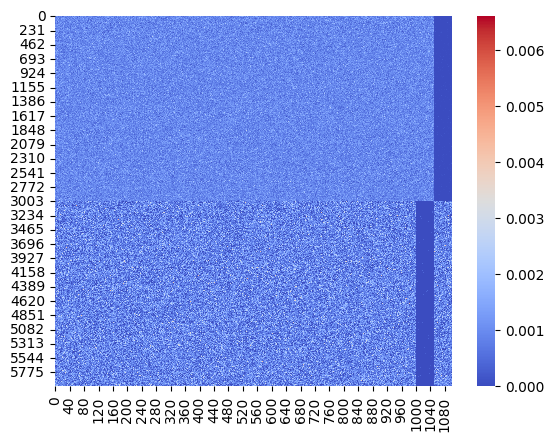

In [17]:
sns.heatmap(P, cmap="coolwarm")

In [6]:
n, m = P_gd.shape
k = 3

In [7]:
gb = InfoGlobe.infoglobe.GlobeEmbedding(A = [n,k], Q = [k,m], c=1)

In [8]:
gb.fit(torch.Tensor(P_gd), max_iter=20000)

  0%|          | 0/20000 [00:00<?, ?it/s]/home/wangcheng/projects/InfoGlobe_ICML/InfoGlobe/infoglobe.py:201: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/home/wangcheng/projects/InfoGlobe_ICML/InfoGlobe/infoglobe.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 20000/20000 [01:30<00:00, 219.98it/s]


20000

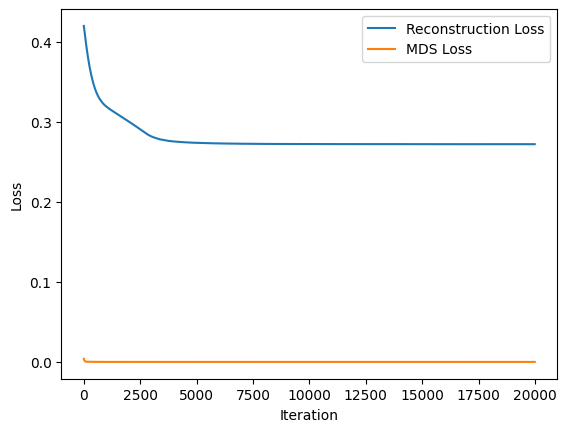

In [9]:
x = [i*10 for i in range(len(gb.loss1))]               

plt.plot(x, gb.loss1, label='Reconstruction Loss')               
plt.plot(x, gb.loss2, label='MDS Loss')                   

plt.xlabel("Iteration")
plt.ylabel("Loss")         
plt.legend()
plt.show()      

In [10]:
adata.obsm['infoglobe_embedding'] = gb.Q.detach().cpu().numpy().T
adata.varm['infoglobe_kernel'] = gb.A.detach().cpu().numpy()

<Axes: >

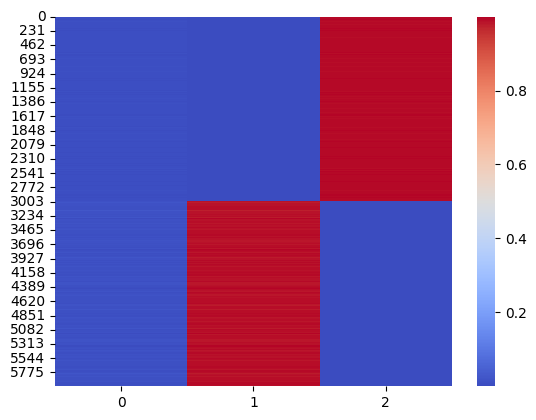

In [16]:
sns.heatmap(adata.obsm['infoglobe_embedding'][:,[1,0,2]], cmap="coolwarm")

In [11]:
fisher_dis_mat = fisher_rao_dis_matrix(torch.tensor(adata.obsm['infoglobe_embedding'].T))
dis_mat, knn_mat = get_knn(fisher_dis_mat, k=50)

adata.obsp['connectivities'] = knn_mat
adata.obsp['distances'] = dis_mat

In [ ]:
adata.uns['neighbors'] = {
    'params': {
        'n_neighbors': 50,
        'method': 'umap',
        'metric': 'fisher_rao',
        # 可以添加其他 Scanpy 期望的参数，如：
        'use_rep': 'infoglobe_embedding', 
    },
    
    # 保持不变：指向 obsp 中的矩阵
    'connectivities_key': 'connectivities',
    'distances_key': 'distances',
}
sc.tl.umap(adata)

/home/wangcheng/anaconda3/envs/MarkovMF/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


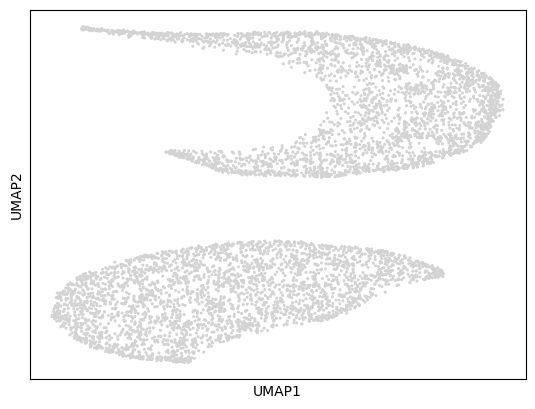

In [13]:
sc.pl.umap(adata,)